170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2068s 12us/step
Original Training Data: (50000, 32, 32, 3)
Original Testing Data : (10000, 32, 32, 3)

After Splitting:
Training Images  : (45000, 32, 32, 3)
Validation Images: (5000, 32, 32, 3)
Testing Images   : (10000, 32, 32, 3)


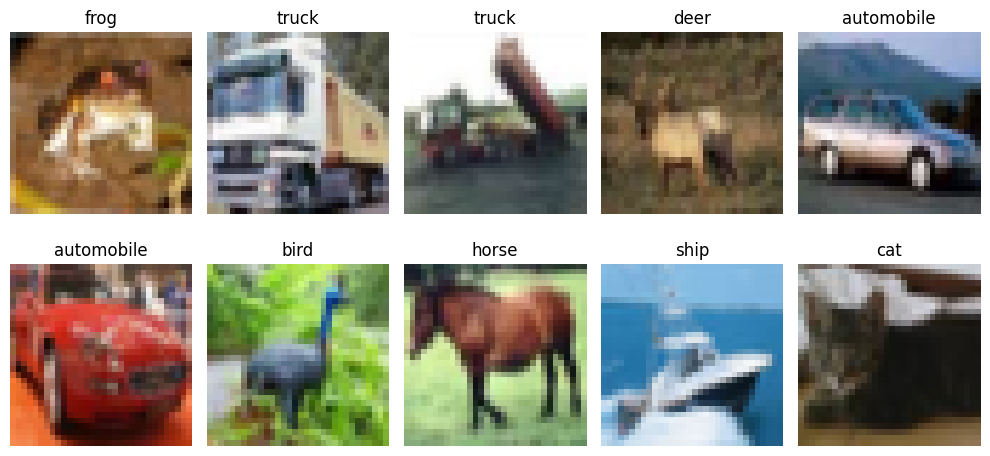

In [1]:
# ============================================
# EXPERIMENT 3 - CNN IMAGE CLASSIFICATION
# PART A: DATASET PREPARATION
# Roll No: 24BAD090
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10

# --------------------------------------------
# 1. Load CIFAR-10 Dataset
# --------------------------------------------

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Original Training Data:", x_train.shape)
print("Original Testing Data :", x_test.shape)

# --------------------------------------------
# 2. Normalize Images
# Pixel values: 0-255 → 0-1
# --------------------------------------------

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# --------------------------------------------
# 3. Split Training Data
# 45,000 Training
# 5,000 Validation
# --------------------------------------------

x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("\nAfter Splitting:")
print("Training Images  :", x_train.shape)
print("Validation Images:", x_val.shape)
print("Testing Images   :", x_test.shape)

# --------------------------------------------
# 4. CIFAR-10 Class Names
# --------------------------------------------

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

# --------------------------------------------
# 5. Display Sample Images
# --------------------------------------------

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [2]:
# ============================================
# EXPERIMENT 3 - CNN IMAGE CLASSIFICATION
# PART B: CNN MODEL IMPLEMENTATION
# Roll No: 24BAD090
# ============================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# --------------------------------------------
# Create CNN Model
# --------------------------------------------

model = Sequential([

    # First Convolution Layer
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    # First Max Pooling Layer
    MaxPooling2D(pool_size=(2, 2)),

    # Second Convolution Layer
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    # Second Max Pooling Layer
    MaxPooling2D(pool_size=(2, 2)),

    # Third Convolution Layer
    Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu"
    ),

    # Convert feature maps into 1D vector
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation="relu"),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output Layer - 10 CIFAR-10 classes
    Dense(10, activation="softmax")
])

# --------------------------------------------
# Display Model Architecture
# --------------------------------------------

model.summary()

# --------------------------------------------
# Compile the Model
# --------------------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nCNN model compiled successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)


CNN model compiled successfully!


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.6150 - loss: 1.0991 - val_accuracy: 0.6676 - val_loss: 0.9545
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.6523 - loss: 0.9970 - val_accuracy: 0.6910 - val_loss: 0.8781
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.6848 - loss: 0.9141 - val_accuracy: 0.6702 - val_loss: 0.9231
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 96ms/step - accuracy: 0.7049 - loss: 0.8544 - val_accuracy: 0.7090 - val_loss: 0.8444
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.7244 - loss: 0.7974 - val_accuracy: 0.7254 - val_loss: 0.8017
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7165 - loss: 0.8179

MODEL TEST RESULTS
Testing Loss     : 0.8179079294204712
Testing Accuracy : 0.7164999842643738


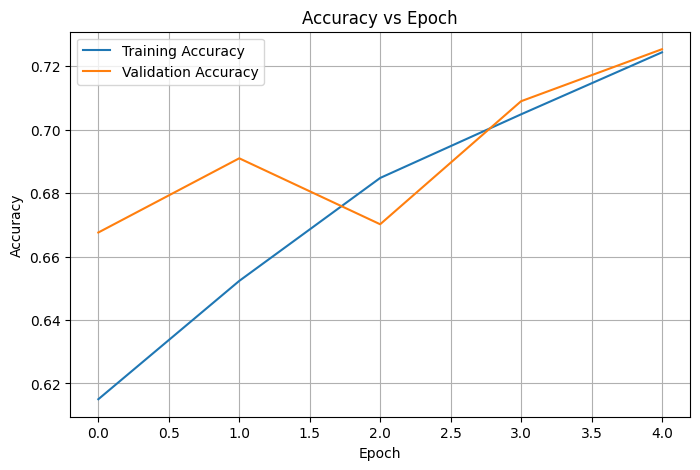

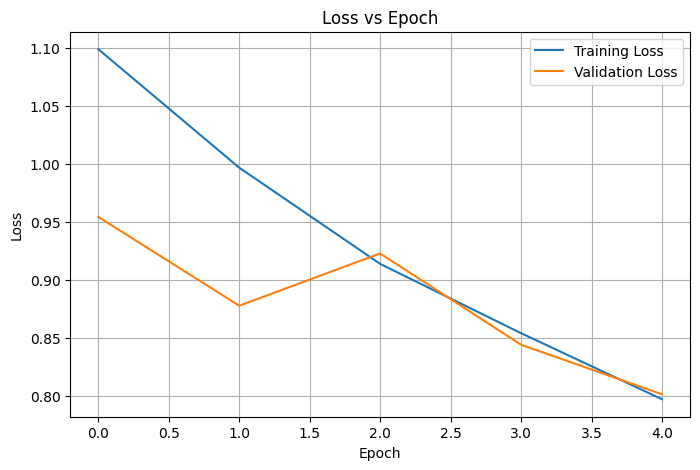

In [4]:
# ============================================
# EXPERIMENT 3 - CNN IMAGE CLASSIFICATION
# PART C: MODEL TRAINING AND EVALUATION
# Roll No: 24BAD090
# ============================================

# --------------------------------------------
# 1. Train the CNN Model
# --------------------------------------------

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_val, y_val)
)

# --------------------------------------------
# 2. Evaluate Model on Test Dataset
# --------------------------------------------

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("\n================================")
print("MODEL TEST RESULTS")
print("================================")

print("Testing Loss     :", test_loss)
print("Testing Accuracy :", test_accuracy)

# --------------------------------------------
# 3. Accuracy vs Epoch
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid()
plt.show()

# --------------------------------------------
# 4. Loss vs Epoch
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Predictions generated successfully!

CLASSIFICATION RESULTS
Total Test Images       : 10000
Correct Predictions     : 7165
Misclassified Images    : 2835
Classification Accuracy : 0.7165


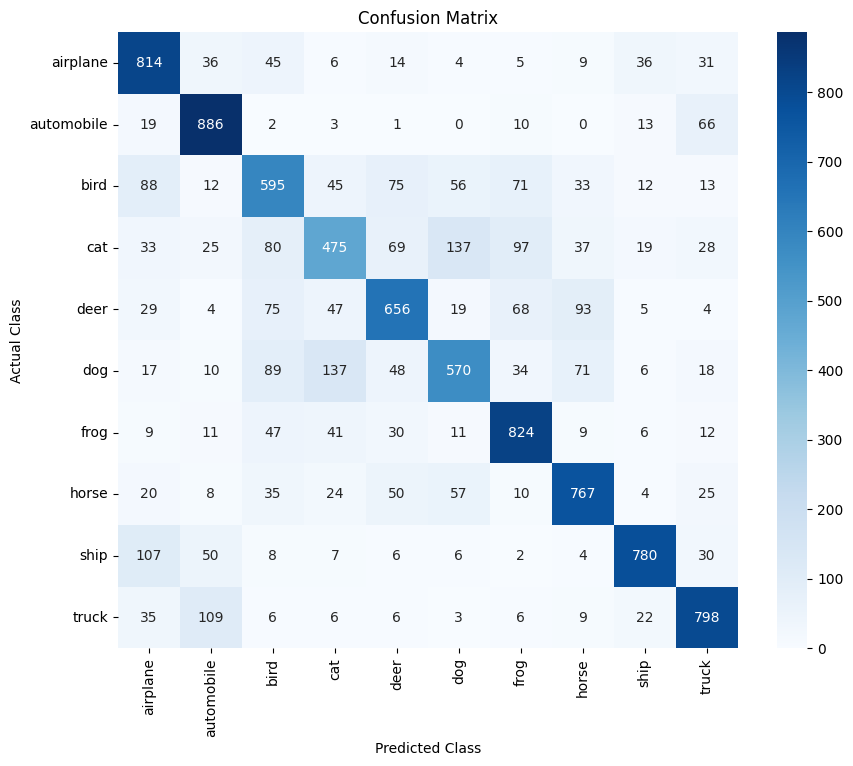

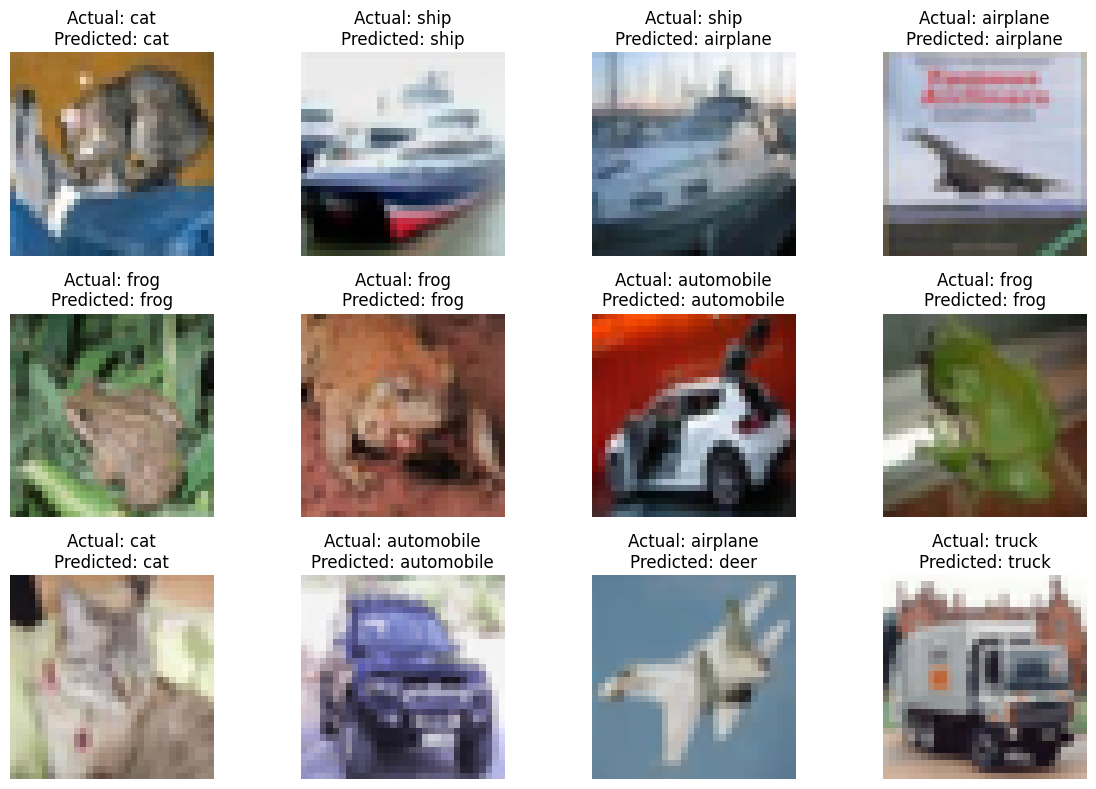


Number of Misclassified Images: 2835


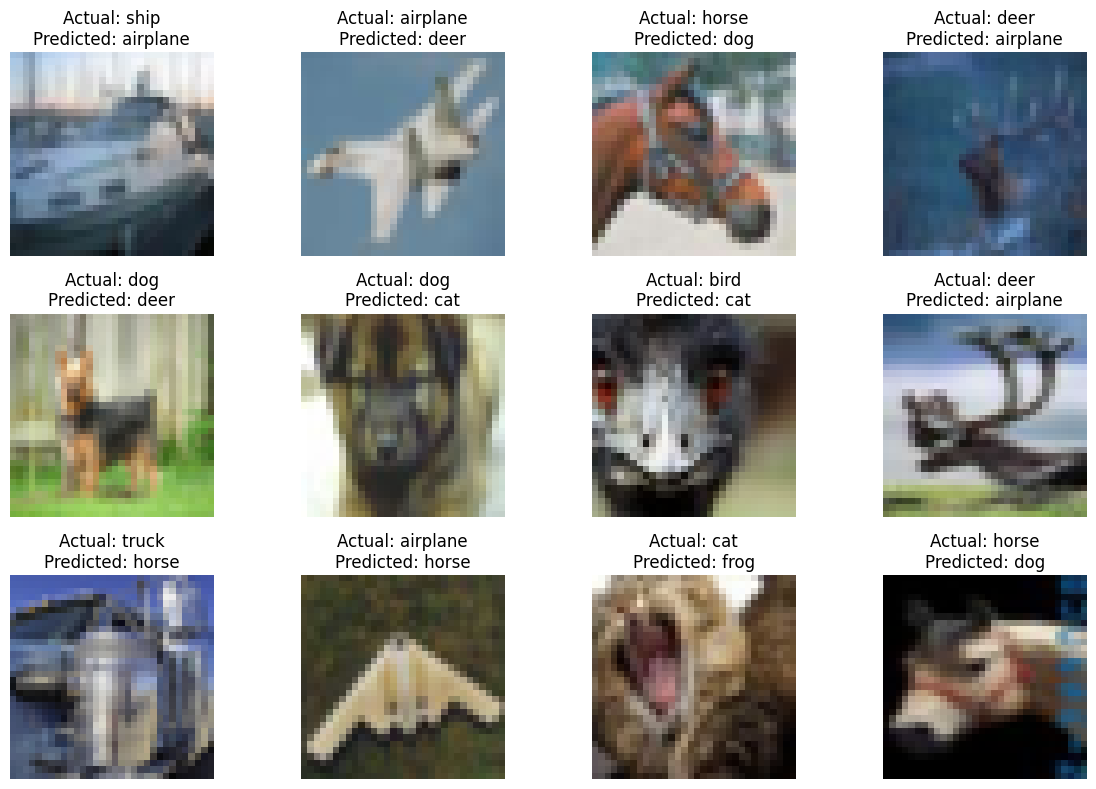

In [5]:
# ============================================
# EXPERIMENT 3 - CNN IMAGE CLASSIFICATION
# PART D: PERFORMANCE ANALYSIS
# Roll No: 24BAD090
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
import seaborn as sns

# --------------------------------------------
# 1. Generate Predictions
# --------------------------------------------

predictions = model.predict(x_test)

# Get class with highest probability
predicted_classes = np.argmax(predictions, axis=1)

actual_classes = y_test.flatten()

print("Predictions generated successfully!")

# --------------------------------------------
# 2. Calculate Correct and Incorrect Results
# --------------------------------------------

correct = np.sum(predicted_classes == actual_classes)
incorrect = np.sum(predicted_classes != actual_classes)

print("\n================================")
print("CLASSIFICATION RESULTS")
print("================================")

print("Total Test Images       :", len(actual_classes))
print("Correct Predictions     :", correct)
print("Misclassified Images    :", incorrect)

accuracy = correct / len(actual_classes)

print("Classification Accuracy :", accuracy)

# --------------------------------------------
# 3. Confusion Matrix
# --------------------------------------------

cm = confusion_matrix(
    actual_classes,
    predicted_classes
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.show()

# --------------------------------------------
# 4. Display Sample Predictions
# --------------------------------------------

plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i])

    actual = class_names[actual_classes[i]]
    predicted = class_names[predicted_classes[i]]

    plt.title(
        "Actual: " + actual +
        "\nPredicted: " + predicted
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# --------------------------------------------
# 5. Find Misclassified Images
# --------------------------------------------

misclassified_indices = np.where(
    predicted_classes != actual_classes
)[0]

print("\nNumber of Misclassified Images:",
      len(misclassified_indices))

# --------------------------------------------
# 6. Display Misclassified Images
# --------------------------------------------

plt.figure(figsize=(12, 8))

for i, index in enumerate(misclassified_indices[:12]):

    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[index])

    actual = class_names[actual_classes[index]]
    predicted = class_names[predicted_classes[index]]

    plt.title(
        "Actual: " + actual +
        "\nPredicted: " + predicted
    )

    plt.axis("off")

plt.tight_layout()
plt.show()